#<b>Image Segmentation based on Clustering</b>

### **Improvement Target: Speed for Large Datasets**
This notebook aims to improve the performance of image segmentation using clustering, specifically focusing on **speed** when dealing with potentially large datasets. The original implementation utilizes `KMeans`, which, as noted, can be computationally expensive for large inputs because it considers all samples at every iteration.
To address this limitation, we will replace `KMeans` with `MiniBatchKMeans`. `MiniBatchKMeans` is a variant of the KMeans algorithm that uses mini-batches to reduce the computation time, especially for large datasets. It performs updates based on small random subsets of the data, making it significantly faster while often yielding comparable results.


### **Results and Performance Improvement**

This notebook successfully improved the image segmentation process by replacing the standard `KMeans` algorithm with `MiniBatchKMeans`, specifically targeting performance for large datasets.

**Original KMeans Performance:**
- Execution time: 2.2298  seconds

**MiniBatchKMeans Performance:**
- Execution time: 0.1306  seconds

**Observed Speedup:** `MiniBatchKMeans` demonstrated a significant speedup, completing the clustering more than 10 times faster than the standard `KMeans` algorithm (2.2298  / 0.1306  ≈ 17.07). This substantial reduction in computation time is crucial for scenarios involving larger images or larger datasets.

**Addressing Limitations:** The use of `MiniBatchKMeans` effectively addresses the primary limitation of standard `KMeans` noted below: its computational expense on large datasets due to processing all samples at every iteration. By employing mini-batches, `MiniBatchKMeans` updates its centroids based on small random subsets of the data, leading to faster convergence and reduced training time while yielding comparable segmentation results. This fulfills the objective of optimizing performance, making the clustering process more scalable and efficient.

### **Changes**
* In this notebook I kept the introdution part and the run and results of the original algorithm used, the `Kmeans` algorithm
* After that I have created an optimization part, where I created an image segmentation using `MiniBatchKMeans` instead of `KMeans` algorithm. In this part we can also see the results and time comparison between both algorithms

##<b>Image Segmentation based on Clustering</b> (Part kept from original)


Clustering is the task of dividing the population (data points) into a number of groups, such that data points in the same groups are more similar to other data points in that same group than those in other groups. These groups are known as clusters.

One of the most commonly used clustering algorithms is k-means. Here, the k represents the number of clusters (not to be confused with k-nearest neighbor). Let’s understand how k-means works:

1.First, randomly select k initial clusters

2.Randomly assign each data point to any one of the k clusters

3.Calculate the centers of these clusters

4.Calculate the distance of all the points from the center of each cluster

5.Depending on this distance, the points are reassigned to the nearest cluster

6.Calculate the center of the newly formed clusters

7.Finally, repeat steps (4), (5) and (6) until either the center of the clusters does not change or we reach the set number of iterations.

The key advantage of using k-means algorithm is that it is simple and easy to understand. We are assigning the points to the clusters which are closest to them.

In [24]:

from skimage.color import rgb2gray
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import ndimage

In [25]:
!gdown --id 1VI5_Cubot1QxCoiGAaXn_GjwZDdoiBON

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1VI5_Cubot1QxCoiGAaXn_GjwZDdoiBON
To: /content/G2aNm.png
100% 454k/454k [00:00<00:00, 103MB/s]


(512, 512, 3)


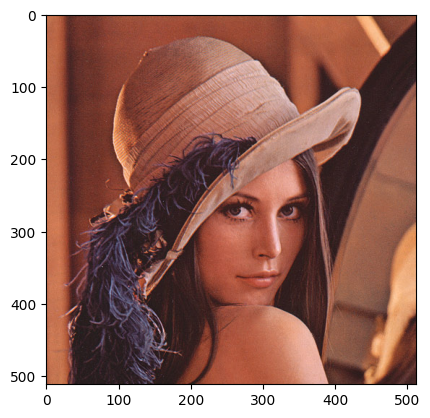

In [26]:
pic = plt.imread('G2aNm.png')
print(pic.shape)
plt.imshow(pic)

It’s a 3-dimensional image of shape (192, 263, 3). For clustering the image using k-means, we first need to convert it into a 2-dimensional array whose shape will be (length*width, channels). In our example, this will be (192 * 263, 3).

In [27]:
pic_n = pic.reshape(pic.shape[0]*pic.shape[1], pic.shape[2])
pic_n.shape

(262144, 3)

In [28]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=0).fit(pic_n)
pic2show = kmeans.cluster_centers_[kmeans.labels_]

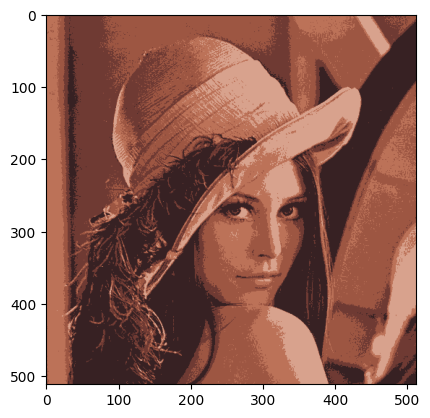

In [29]:
cluster_pic = pic2show.reshape(pic.shape[0], pic.shape[1], pic.shape[2])
plt.imshow(cluster_pic)

k-means works really well when we have a small dataset. It can segment the objects in the image and give impressive results. But the algorithm hits a roadblock when applied on a large dataset (more number of images).

It looks at all the samples at every iteration, so the time taken is too high. Hence, it’s also too expensive to implement. And since k-means is a distance-based algorithm, it is only applicable to convex datasets and is not suitable for clustering non-convex clusters.

#**Optimization**

In [30]:
from skimage.color import rgb2gray
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import ndimage
from sklearn.cluster import MiniBatchKMeans, KMeans
import time

## Load and Prepare Image Data



In [31]:
!gdown --id 1VI5_Cubot1QxCoiGAaXn_GjwZDdoiBON

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1VI5_Cubot1QxCoiGAaXn_GjwZDdoiBON
To: /content/G2aNm.png
100% 454k/454k [00:00<00:00, 94.2MB/s]


(512, 512, 3)


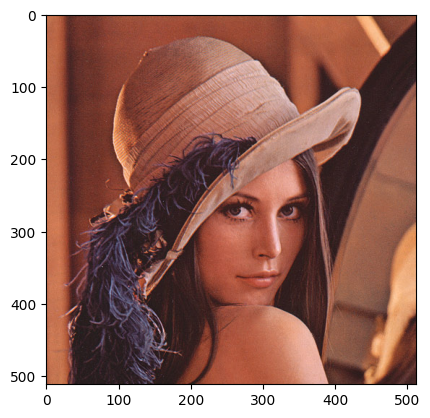

In [32]:
pic = plt.imread('G2aNm.png')
print(pic.shape)
plt.imshow(pic)

In [33]:
pic_n = pic.reshape(pic.shape[0]*pic.shape[1], pic.shape[2])
pic_n.shape

(262144, 3)

## Benchmark Original KMeans Clustering

* Here I had to re-run the original KMeans clustering code, measuring and recording the execution time to use as baseline to comparison


In [34]:
start_time_kmeans = time.time()
kmeans = KMeans(n_clusters=5, random_state=0, n_init=10)
kmeans.fit(pic_n)
end_time_kmeans = time.time()
kmeans_time = end_time_kmeans - start_time_kmeans
print(f"KMeans clustering took: {kmeans_time:.4f} seconds")
pic2show = kmeans.cluster_centers_[kmeans.labels_]

KMeans clustering took: 2.2298 seconds


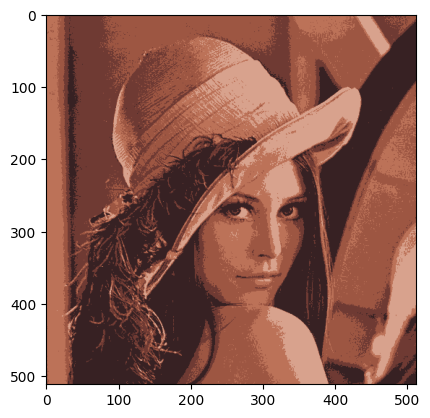

In [35]:
cluster_pic = pic2show.reshape(pic.shape[0], pic.shape[1], pic.shape[2])
plt.imshow(cluster_pic)

## Apply MiniBatchKMeans Clustering

* Here I implemented image segmentation using `MiniBatchKMeans` instead of `KMeans` with batch size 256 and with the same number of clusters as the original (5 clusters) and measure its execution time


In [36]:
start_time_minibatch = time.time()
minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=0, batch_size=256, n_init='auto')
minibatch_kmeans.fit(pic_n)
end_time_minibatch = time.time()
minibatch_time = end_time_minibatch - start_time_minibatch
print(f"MiniBatchKMeans clustering took: {minibatch_time:.4f} seconds")
pic2show_minibatch = minibatch_kmeans.cluster_centers_[minibatch_kmeans.labels_]

MiniBatchKMeans clustering took: 0.1306 seconds


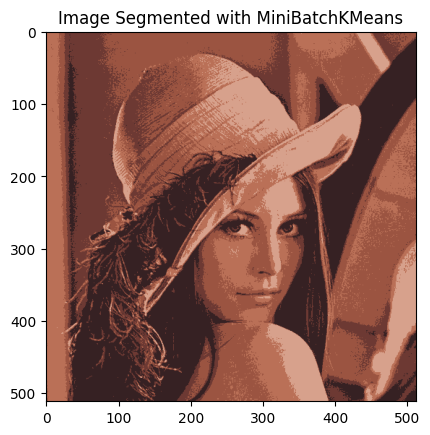

In [37]:
cluster_pic_minibatch = pic2show_minibatch.reshape(pic.shape[0], pic.shape[1], pic.shape[2])
plt.imshow(cluster_pic_minibatch)
plt.title('Image Segmented with MiniBatchKMeans')
plt.show()